In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [7]:
# Define mayoral terms
mayor_terms = {
    "Mamdani": pd.date_range(start="2026-01-01", end=pd.Timestamp.today(), freq="D"),
    "Adams": pd.date_range(start="2022-01-01", end="2025-12-31", freq="D"),
    "de Blasio": pd.date_range(start="2014-01-01", end="2021-12-31", freq="D"),
}

In [8]:
# Load pothole work order data
potholes = gpd.read_file("../data/raw/Street_Pothole_Work_Orders_-_Closed_(Dataset).geojson")

print(f"data loaded: {len(potholes)} rows x {len(potholes.columns)} columns")
potholes.head()

data loaded: 401594 rows x 19 columns


,:id,:version,:created_at,:updated_at,defnum,initby,housenum,oft,onfacename,onprimname,frmprimnam,toprimname,specloc,boro,source,rptdate,rptclosed,shape_leng,geometry
0,row-jx8m.gdpq-y3ua,rv-6qef~j48j_5b9e,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004041154,YRD,None,373480377030377030,ROCKAWAY PY,ROCKAWAY PARKWAY,BELT PARKWAY,BELT PARKWAY,None,B,YRD,2004-02-08,2023-01-27,557.690464852,"MULTILINESTRING ((-73.88643 40.63078, -73.8860..."
1,row-mi7k_dc5y~e33f,rv-dzgk~n5m2_gvx9,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2004287021,CSC,None,318630377030377030,BEDFORD AV,BEDFORD AVENUE,BELT PARKWAY,BELT PARKWAY,SB ON BEDFORD_UNDERNEATH OVERPASS,B,CTZ,2004-10-13,2013-02-14,109.124234309,"MULTILINESTRING ((-73.94381 40.58499, -73.9438..."
2,row-8wxg_rmxu_et2s,rv-wxhh_pdb9.2rzt,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2006085009,CSC,None,306380308480308530,13 AV,13 AVENUE,38 STREET,39 STREET,I/F/O B16 BUS STOP,B,CTZ,2006-03-26,2014-10-11,260.495098096,"MULTILINESTRING ((-73.98571 40.64119, -73.9862..."
3,row-w2jj_j5em~gjk4,rv-bwbx_nhbh.sbcs,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2007166005,CSC,1688,342730355530375430,FULTON ST,FULTON STREET,LEWIS AVENUE,SCHENECTADY AVENUE,POTHOLE NEAR CURB I/F/O ADDRESS,B,CTZ,2007-06-15,2011-01-14,549.255973307,"MULTILINESTRING ((-73.93487 40.67959, -73.9343..."
4,row-mje4.qtar~cgsu,rv-kse4.pez2_yrib,2026-04-30 19:41:04.386000+00:00,2026-04-30 19:41:04.386000+00:00,DB2009352004,CSC,45,380030331530342730,ST FELIX ST,ST FELIX STREET,DEKALB AVENUE,FULTON STREET,"4"" DEEP",B,CTZ,2009-12-18,2010-01-06,836.436669174,"MULTILINESTRING ((-73.97794 40.68981, -73.9775..."


In [9]:
# Clean pothole work order data and cast data types
potholes = potholes.drop(columns = [col for col in potholes.columns if col[0] == ":"]) # drop metadata cols 

dtype_schema = {
    "numeric": ["shape_leng"],
    "category": ["boro"],
    "datetime": ["rptdate", "rptclosed"],
    "object": ["defnum", "initby", "housenum", "oft", "onfacename", "onprimname", "frmprimnam", "toprimname", "specloc", "source"]
}

for col in potholes.columns:
    if col == "geometry":
        continue # leave geometry untouched
    elif col in dtype_schema["numeric"]:
        potholes[col] = pd.to_numeric(potholes[col]) 
    elif col in dtype_schema["category"]:
        potholes[col] = potholes[col].astype("category") 
    elif col in dtype_schema["datetime"]:
        potholes[col] = pd.to_datetime(potholes[col])
    elif col in dtype_schema["object"]:
        potholes[col] = potholes[col].astype(str)
    else: 
        print(f"Warning: {col} not in schema")

# Create new cols
potholes["response_time"] = ((potholes["rptclosed"] - potholes["rptdate"])).dt.days

In [10]:
# Create daily pothole work order rollup
full_range = pd.period_range(start='2011-01-01', end='2030-12-31', freq='D')

potholes_clsd_by_day = (
    potholes.groupby(potholes["rptclosed"].dt.to_period('D').rename("day"), observed=False, dropna=False)
    .agg(count=("defnum", "count"))
    .reset_index()
    .set_index("day")
    .reindex(full_range, fill_value=0) # fill days that don't appear with 0 count so they don't get dropped
    .rename_axis("day")
    .reset_index()
)

potholes_clsd_by_day["month"] = potholes_clsd_by_day["day"].dt.month
potholes_clsd_by_day["year"] = potholes_clsd_by_day["day"].dt.year

In [11]:
# Calculate average work orders closed by day
print(f"Average work orders closed by day: {potholes_clsd_by_day["count"].mean():.1f}\nMedian work orders closed by day {potholes_clsd_by_day["count"].median():.1f}")

Average work orders closed by day: 51.0
Median work orders closed by day 32.0


In [12]:
# Compile first 100 day counts by mayor
first100 = pd.DataFrame()

for mayor, term in mayor_terms.items():
    timeframe = (potholes_clsd_by_day["day"].dt.to_timestamp() >= term[0]) & (potholes_clsd_by_day["day"].dt.to_timestamp() <= term[99])
    subset = potholes_clsd_by_day[timeframe].copy()
    subset["mayor"] = mayor
    first100 = pd.concat([first100, subset])

# Add cumulative count and day numbers
first100["day_num"] = first100.groupby("mayor").cumcount() + 1
first100["count_cumulative"] = first100.groupby("mayor")["count"].cumsum()

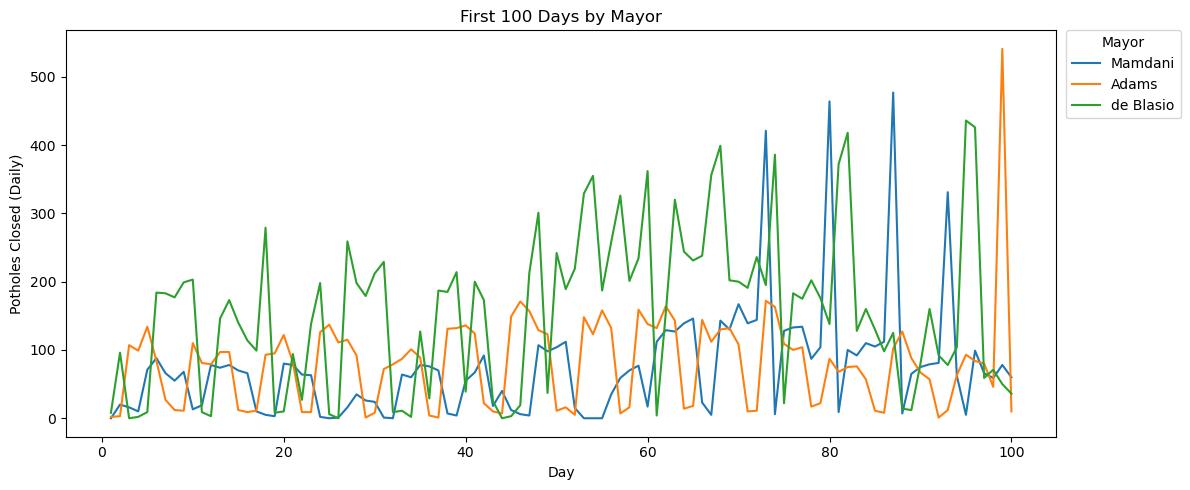

In [13]:
# Plot first 100 days comparison
fig, ax = plt.subplots(figsize=(12, 5))

for mayor in first100["mayor"].unique():
    subset = first100[first100["mayor"] == mayor]
    ax.plot(subset["day_num"], subset["count"], label=mayor)


ax.set_title("First 100 Days by Mayor")
ax.legend(title="Mayor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_xlabel("Day")
ax.set_ylabel("Potholes Closed (Daily)")
plt.tight_layout()
plt.show()

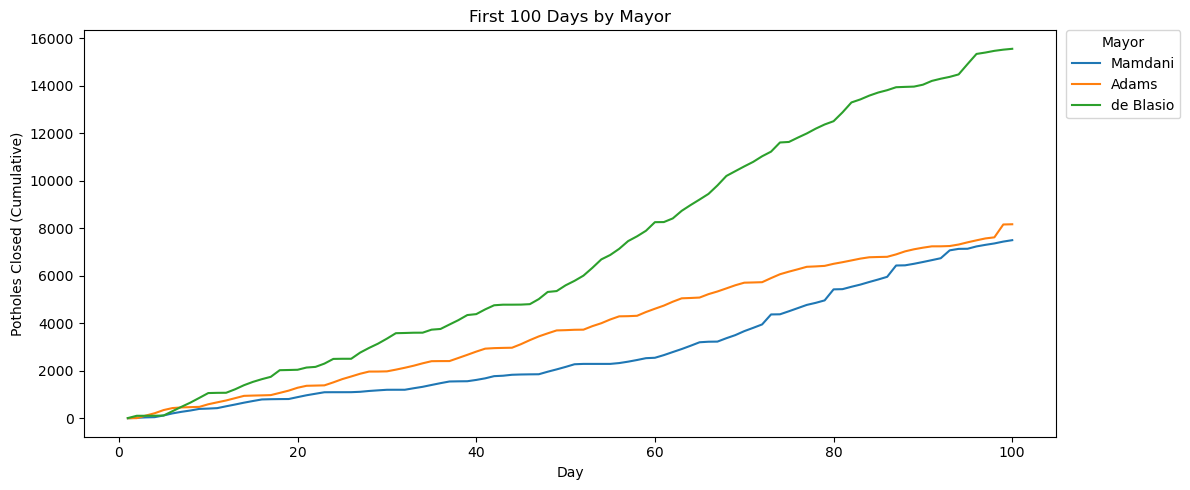

In [14]:
# Plot first 100 days cumulative counts
fig, ax = plt.subplots(figsize=(12, 5))

for mayor in first100["mayor"].unique():
    subset = first100[first100["mayor"] == mayor]
    ax.plot(subset["day_num"], subset["count_cumulative"], label=mayor)


ax.set_title("First 100 Days by Mayor")
ax.legend(title="Mayor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_xlabel("Day")
ax.set_ylabel("Potholes Closed (Cumulative)")
plt.tight_layout()
plt.show()

In [15]:
# Compile most productive 100 day counts by mayor
best100 = pd.DataFrame()

for mayor, term in mayor_terms.items():
    mayor_data = potholes_clsd_by_day[(potholes_clsd_by_day["day"].dt.to_timestamp() >= term[0]) & (potholes_clsd_by_day["day"].dt.to_timestamp() <= term[-1])].copy()
    
    if mayor == "Mamdani":
        subset = mayor_data.iloc[:100].copy() # use first 100 for Mamadani as comparison
    else:
        rolling = mayor_data["count"].rolling(100).sum()
        best_end_pos = mayor_data.index.get_loc(rolling.idxmax())
        best_start_pos = best_end_pos - 99
        subset = mayor_data.iloc[best_start_pos:best_end_pos + 1].copy()
    
    subset["mayor"] = mayor
    best100 = pd.concat([best100, subset])

# Add cumulative count and day numbers
best100["day_num"] = best100.groupby("mayor").cumcount() + 1
best100["count_cumulative"] = best100.groupby("mayor")["count"].cumsum()

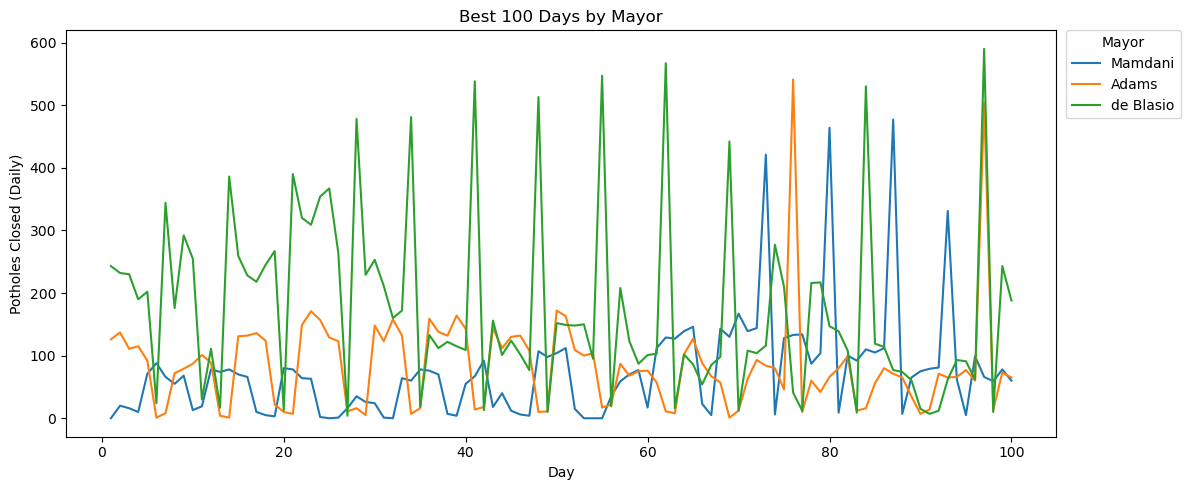

In [16]:
# Plot best 100 days comparison
fig, ax = plt.subplots(figsize=(12, 5))

for mayor in best100["mayor"].unique():
    subset = best100[best100["mayor"] == mayor]
    ax.plot(subset["day_num"], subset["count"], label=mayor)


ax.set_title("Best 100 Days by Mayor")
ax.legend(title="Mayor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_xlabel("Day")
ax.set_ylabel("Potholes Closed (Daily)")
plt.tight_layout()
plt.show()

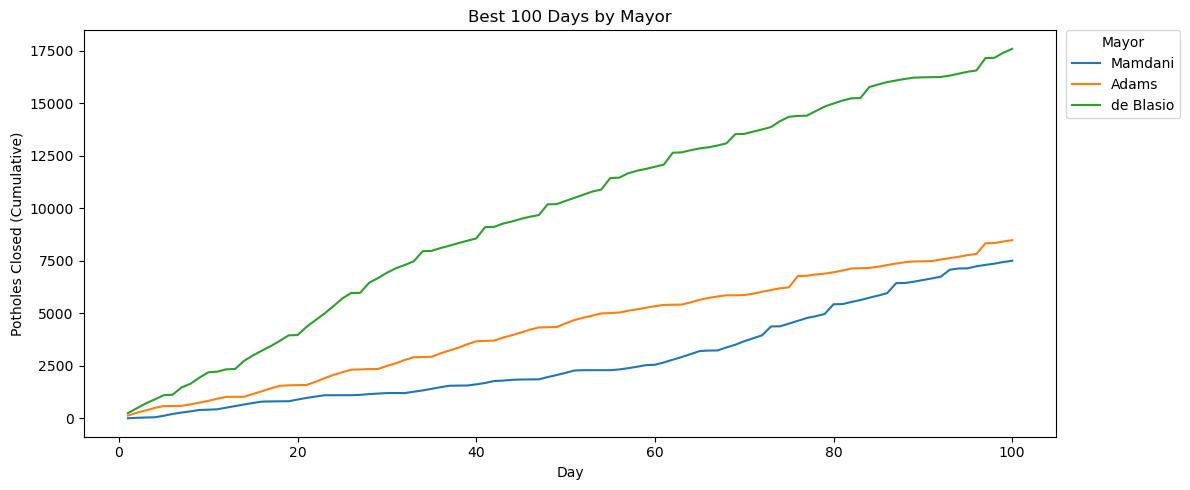

In [17]:
# Plot best 100 days cumulative count
fig, ax = plt.subplots(figsize=(12, 5))

for mayor in best100["mayor"].unique():
    subset = best100[best100["mayor"] == mayor]
    ax.plot(subset["day_num"], subset["count_cumulative"], label=mayor)


ax.set_title("Best 100 Days by Mayor")
ax.legend(title="Mayor", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
ax.set_xlabel("Day")
ax.set_ylabel("Potholes Closed (Cumulative)")
plt.tight_layout()
plt.show()

In [18]:
# Get blitz dates as number of day in office
blitz_dates = ["2026-03-14", "2026-03-21", "2026-03-28", "2026-04-11"]

for index_1, date in enumerate(blitz_dates):
    for index_2, day in enumerate(mayor_terms["Mamdani"]):
        if pd.to_datetime(date) == day:
            print(f"Pothole blitz {index_1+1} was on Mamdani's {index_2+1} day in office")

Pothole blitz 1 was on Mamdani's 73 day in office
Pothole blitz 2 was on Mamdani's 80 day in office
Pothole blitz 3 was on Mamdani's 87 day in office
Pothole blitz 4 was on Mamdani's 101 day in office


In [19]:
# Identify day numbers of best 100 day streak
for mayor in best100["mayor"].unique():
    subset = best100[best100["mayor"] == mayor]
    start = subset["day"].iloc[0].to_timestamp()
    end = subset["day"].iloc[-1].to_timestamp()
    first_day = (start - mayor_terms[mayor][0]).days + 1
    last_day = (end - mayor_terms[mayor][0]).days + 1
    
    print(f"{mayor}'s best 100 days were from days {first_day} to {last_day}")

Mamdani's best 100 days were from days 1 to 100
Adams's best 100 days were from days 24 to 123
de Blasio's best 100 days were from days 419 to 518


In [20]:
# Export Data
first100.to_csv("../data/processed/nyc_mayor_potholes_first100.csv")
best100.to_csv("../data/processed/nyc_mayor_potholes_best100.csv")